 # Diagnostic: Matched Filter vs Threshold Detection
 This notebook compares matched filtering detection with simple thresholding
 and provides detailed visualizations to understand why spikes may be missed or false-detected.

In [10]:
# === Imports & Config Loading ===
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path
from scipy.signal import correlate
from scipy.ndimage import gaussian_filter1d

import spikeinterface as si
import spikeinterface.preprocessing as spre
import spikeinterface.extractors as se
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

# Add parent dir to path so we can import RCP_analysis
REPO_ROOT = Path(os.getcwd()).resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

In [34]:
# === CONFIGURATION - EDIT THESE ===

# Session to analyze (Must match a folder in results/checkpoints/UA/)
SESSION_NAME = "NRR_RW022_001"

# Path to preprocessed recording (Uses SESSION_NAME by default)
# Set to None if you want to preprocess on the fly
PREPROCESSED_PATH = UA_CKPT_ROOT / f"pp__{SESSION_NAME}__NS6"

# Template path (Relative to Repo Root)
TEMPLATE_PATH = REPO_ROOT / "config" / "median_extremum_templates_norm_UA_PortB.npy"

# Channel to visualize (electrode number, not index)
DEBUG_ELECTRODE = 24

# Time window to visualize (in ms from recording start)
TIME_WINDOW_MS = (5000, 10000)

# Detection parameters
THRESH_SIMPLE = 4.0  # For simple thresholding
THRESH_MF = 3.5      # For matched filtering
PEAK_SIGN = "neg"
HIGHPASS_HZ = 300.0

# Verify Paths
print(f"Project Root: {REPO_ROOT}")
if not PREPROCESSED_PATH.exists():
    print(f"⚠️  WARNING: Preprocessed path not found: {PREPROCESSED_PATH}")
    print(f"   Check if your params.yaml 'location' matches {SESSION_NAME.split('_')[0]}")

Project Root: E:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis


In [35]:
# === LOAD DATA ===

print(f"Loading session: {SESSION_NAME}")

# if PREPROCESSED_PATH and PREPROCESSED_PATH.exists():
#     print(f"Loading preprocessed recording from: {PREPROCESSED_PATH}")
#     rec = si.load_extractor(PREPROCESSED_PATH)
# else:
print("Loading raw and preprocessing on the fly...")
# Try to find the session folder in BR_ROOT
sess_path = BR_ROOT / SESSION_NAME
if not sess_path.exists():
    # Fallback: maybe it's just the index and we need the full session string?
    # Typically SESSION_NAME is NRR_RW022_015
    print(f"⚠️  Raw session path not found: {sess_path}")
rec_raw = se.read_blackrock(sess_path, stream_name='nsx6', all_annotations=True)

# Apply channel mapping
XLS = rcp.ua_excel_path(REPO_ROOT, PARAMS.probes)
UA_MAP = rcp.load_UA_mapping_from_excel(XLS)
br_idx = int(SESSION_NAME.split('_')[-1])

rec_raw, idx_rows, ua_elec, ua_nsp, ua_region, ua_region_names, ua_port = \
    rcp.apply_ua_mapping_with_regions(rec_raw, UA_MAP, br_idx, METADATA_CSV)

# Highpass filter
rec = spre.highpass_filter(rec_raw, freq_min=HIGHPASS_HZ)

fs = rec.get_sampling_frequency()
print(f"Sampling frequency: {fs} Hz")
print(f"Recording duration: {rec.get_total_duration():.1f} s")
print(f"Number of channels: {rec.get_num_channels()}")

# Verify sampling rate
if abs(fs - 30000.0) > 1.0:
    print(f"⚠️  WARNING: Sampling rate is {fs} Hz, not 30000 Hz!")
    print("   Template may need resampling!")

Loading session: NRR_RW022_001
Loading raw and preprocessing on the fly...
⚠️  Raw session path not found: \\cullenstor.win.ad.jhu.edu\data\Current Project Databases - NHP\2025 Cerebellum prosthesis\Nike\20260311_NRR_RW022\Blackrock\NRR_RW022_001
[MAP] UA port from metadata: 'B'
[MAP] Applying NSP offset for Port B: local 1..128 -> NSP 129..256
[MAP] renamed 128/128 rows with UA mapping ('UAe###_NSP###') using port 'B'.
Sampling frequency: 30000.0 Hz
Recording duration: 106.0 s
Number of channels: 128



Loading template from: E:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis\config\median_extremum_templates_norm_UA_PortB.npy
Template shape: (105,)
Template length: 105 samples = 3.50 ms
Peak at sample 45 (1.500 ms from start)


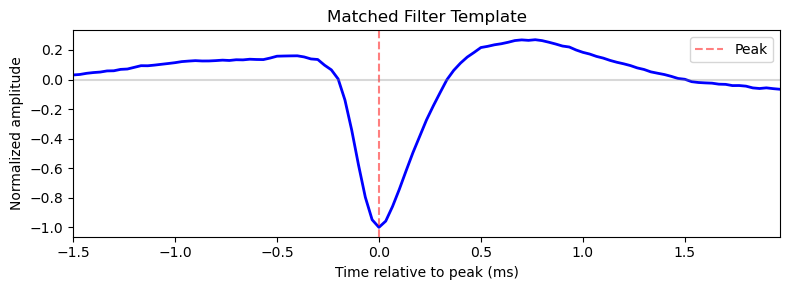

In [36]:
# === LOAD TEMPLATE ===

print(f"\nLoading template from: {TEMPLATE_PATH}")
template = np.load(TEMPLATE_PATH)
print(f"Template shape: {template.shape}")
print(f"Template length: {len(template)} samples = {len(template)/fs*1000:.2f} ms")

# Find the negative peak (trough) position
nbefore = np.argmin(template)
nafter = len(template) - nbefore
ms_before = nbefore / fs * 1000
ms_after = nafter / fs * 1000
print(f"Peak at sample {nbefore} ({ms_before:.3f} ms from start)")

# Plot template
fig, ax = plt.subplots(figsize=(8, 3))
t_template = (np.arange(len(template)) - nbefore) / fs * 1000
ax.plot(t_template, template, 'b-', lw=2)
ax.axvline(0, color='r', linestyle='--', alpha=0.5, label='Peak')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time relative to peak (ms)')
ax.set_ylabel('Normalized amplitude')
ax.set_title('Matched Filter Template')
ax.legend()
ax.set_xlim(t_template[0], t_template[-1])
plt.tight_layout()
plt.show()

In [37]:
# === FIND DEBUG CHANNEL ===

# Get channel mapping info
ch_ids = rec.get_channel_ids()

# Try to find the electrode
if 'ua_elec' in dir():
    # If we have electrode mapping from preprocessing
    debug_ch_idx = None
    for i, elec in enumerate(ua_elec):
        if int(elec) == DEBUG_ELECTRODE:
            debug_ch_idx = i
            break
    if debug_ch_idx is None:
        print(f"⚠️  Electrode {DEBUG_ELECTRODE} not found in mapping, using channel index 0")
        debug_ch_idx = 0
else:
    # Just use as index
    debug_ch_idx = min(DEBUG_ELECTRODE, len(ch_ids) - 1)

debug_ch_id = ch_ids[debug_ch_idx]
print(f"\nDebug channel: index={debug_ch_idx}, id={debug_ch_id}")


Debug channel: index=2, id=UAe024_NSP131


In [38]:
# === EXTRACT TIME WINDOW ===

t0_ms, t1_ms = TIME_WINDOW_MS
t0_samp = int(t0_ms * fs / 1000)
t1_samp = int(t1_ms * fs / 1000)

# Bounds check
n_samples = rec.get_num_samples()
t0_samp = max(0, t0_samp)
t1_samp = min(n_samples, t1_samp)

print(f"\nExtracting window: {t0_ms:.1f} - {t1_ms:.1f} ms")
print(f"Sample range: {t0_samp} - {t1_samp} ({t1_samp - t0_samp} samples)")

# Get trace for debug channel
trace = rec.get_traces(
    start_frame=t0_samp, 
    end_frame=t1_samp, 
    channel_ids=[debug_ch_id],
    return_in_uV=True
).flatten()

t_ms = np.arange(len(trace)) / fs * 1000 + t0_ms

print(f"Trace stats: min={trace.min():.1f}, max={trace.max():.1f}, std={trace.std():.1f} µV")


Extracting window: 5000.0 - 10000.0 ms
Sample range: 150000 - 300000 (150000 samples)
Trace stats: min=-31.5, max=37.5, std=5.1 µV


In [39]:
# === COMPUTE MATCHED FILTER OUTPUT ===

print("\nComputing matched filter output...")

# Flip template for convolution (correlation = convolution with flipped kernel)
# Actually, scipy.correlate handles this, but let's be explicit
mf_output = correlate(trace, template, mode='same')

# Normalize by template energy for interpretability
template_energy = np.sqrt(np.sum(template**2))
mf_output_norm = mf_output / template_energy

print(f"MF output stats: min={mf_output_norm.min():.1f}, max={mf_output_norm.max():.1f}, std={mf_output_norm.std():.1f}")


Computing matched filter output...
MF output stats: min=-62.5, max=79.1, std=11.8


In [40]:
# === COMPUTE NOISE LEVEL ===

# MAD-based noise estimate
noise_level = np.median(np.abs(trace - np.median(trace))) / 0.6745
print(f"Estimated noise level (MAD): {noise_level:.2f} µV")

# Threshold in µV
thresh_uV = THRESH_SIMPLE * noise_level
print(f"Simple threshold ({THRESH_SIMPLE}σ): {thresh_uV:.1f} µV")

Estimated noise level (MAD): 5.19 µV
Simple threshold (4.0σ): 20.8 µV


In [41]:
# === SIMPLE THRESHOLD DETECTION (manual) ===

print("\nRunning simple threshold detection (manual)...")

if PEAK_SIGN == "neg":
    # Find local minima below threshold
    below_thresh = trace < -thresh_uV
elif PEAK_SIGN == "pos":
    below_thresh = trace > thresh_uV
else:  # both
    below_thresh = np.abs(trace) > thresh_uV

# Find threshold crossings
crossings = np.where(np.diff(below_thresh.astype(int)) == 1)[0]

# For each crossing, find the local extremum
simple_peak_idx = []
simple_peak_amp = []
for c in crossings:
    # Search window around crossing
    win_start = max(0, c - int(0.5 * fs / 1000))  # 0.5 ms before
    win_end = min(len(trace), c + int(1.5 * fs / 1000))  # 1.5 ms after
    
    if PEAK_SIGN == "neg":
        local_min_idx = win_start + np.argmin(trace[win_start:win_end])
        if trace[local_min_idx] < -thresh_uV:
            simple_peak_idx.append(local_min_idx)
            simple_peak_amp.append(trace[local_min_idx])
    elif PEAK_SIGN == "pos":
        local_max_idx = win_start + np.argmax(trace[win_start:win_end])
        if trace[local_max_idx] > thresh_uV:
            simple_peak_idx.append(local_max_idx)
            simple_peak_amp.append(trace[local_max_idx])

# Remove duplicates (peaks found multiple times)
simple_peak_idx = np.array(simple_peak_idx)
simple_peak_amp = np.array(simple_peak_amp)

if len(simple_peak_idx) > 1:
    # Keep only peaks separated by at least 0.5 ms
    min_sep = int(0.5 * fs / 1000)
    keep = [0]
    for i in range(1, len(simple_peak_idx)):
        if simple_peak_idx[i] - simple_peak_idx[keep[-1]] >= min_sep:
            keep.append(i)
    simple_peak_idx = simple_peak_idx[keep]
    simple_peak_amp = simple_peak_amp[keep]

print(f"Simple threshold found {len(simple_peak_idx)} peaks")


Running simple threshold detection (manual)...
Simple threshold found 29 peaks


In [42]:
# === MATCHED FILTER PEAK DETECTION (manual) ===

print("\nRunning matched filter detection (manual)...")

# Threshold on MF output
mf_noise = np.median(np.abs(mf_output_norm - np.median(mf_output_norm))) / 0.6745
mf_thresh = THRESH_MF * mf_noise

print(f"MF noise level: {mf_noise:.2f}")
print(f"MF threshold ({THRESH_MF}σ): {mf_thresh:.1f}")

if PEAK_SIGN == "neg":
    # For negative spikes, MF output has negative peaks
    mf_below = mf_output_norm < -mf_thresh
    mf_crossings = np.where(np.diff(mf_below.astype(int)) == 1)[0]
elif PEAK_SIGN == "pos":
    mf_above = mf_output_norm > mf_thresh
    mf_crossings = np.where(np.diff(mf_above.astype(int)) == 1)[0]
else:
    mf_above = np.abs(mf_output_norm) > mf_thresh
    mf_crossings = np.where(np.diff(mf_above.astype(int)) == 1)[0]

# Find local extrema
mf_peak_idx = []
mf_peak_amp = []
for c in mf_crossings:
    win_start = max(0, c - int(0.5 * fs / 1000))
    win_end = min(len(mf_output_norm), c + int(1.5 * fs / 1000))
    
    if PEAK_SIGN == "neg":
        local_idx = win_start + np.argmin(mf_output_norm[win_start:win_end])
        mf_peak_idx.append(local_idx)
        mf_peak_amp.append(mf_output_norm[local_idx])
    else:
        local_idx = win_start + np.argmax(mf_output_norm[win_start:win_end])
        mf_peak_idx.append(local_idx)
        mf_peak_amp.append(mf_output_norm[local_idx])

# Remove duplicates
mf_peak_idx = np.array(mf_peak_idx)
mf_peak_amp = np.array(mf_peak_amp)

if len(mf_peak_idx) > 1:
    min_sep = int(0.5 * fs / 1000)
    keep = [0]
    for i in range(1, len(mf_peak_idx)):
        if mf_peak_idx[i] - mf_peak_idx[keep[-1]] >= min_sep:
            keep.append(i)
    mf_peak_idx = mf_peak_idx[keep]
    mf_peak_amp = mf_peak_amp[keep]

print(f"Matched filter found {len(mf_peak_idx)} peaks")


Running matched filter detection (manual)...
MF noise level: 11.55
MF threshold (3.5σ): 40.4
Matched filter found 12 peaks


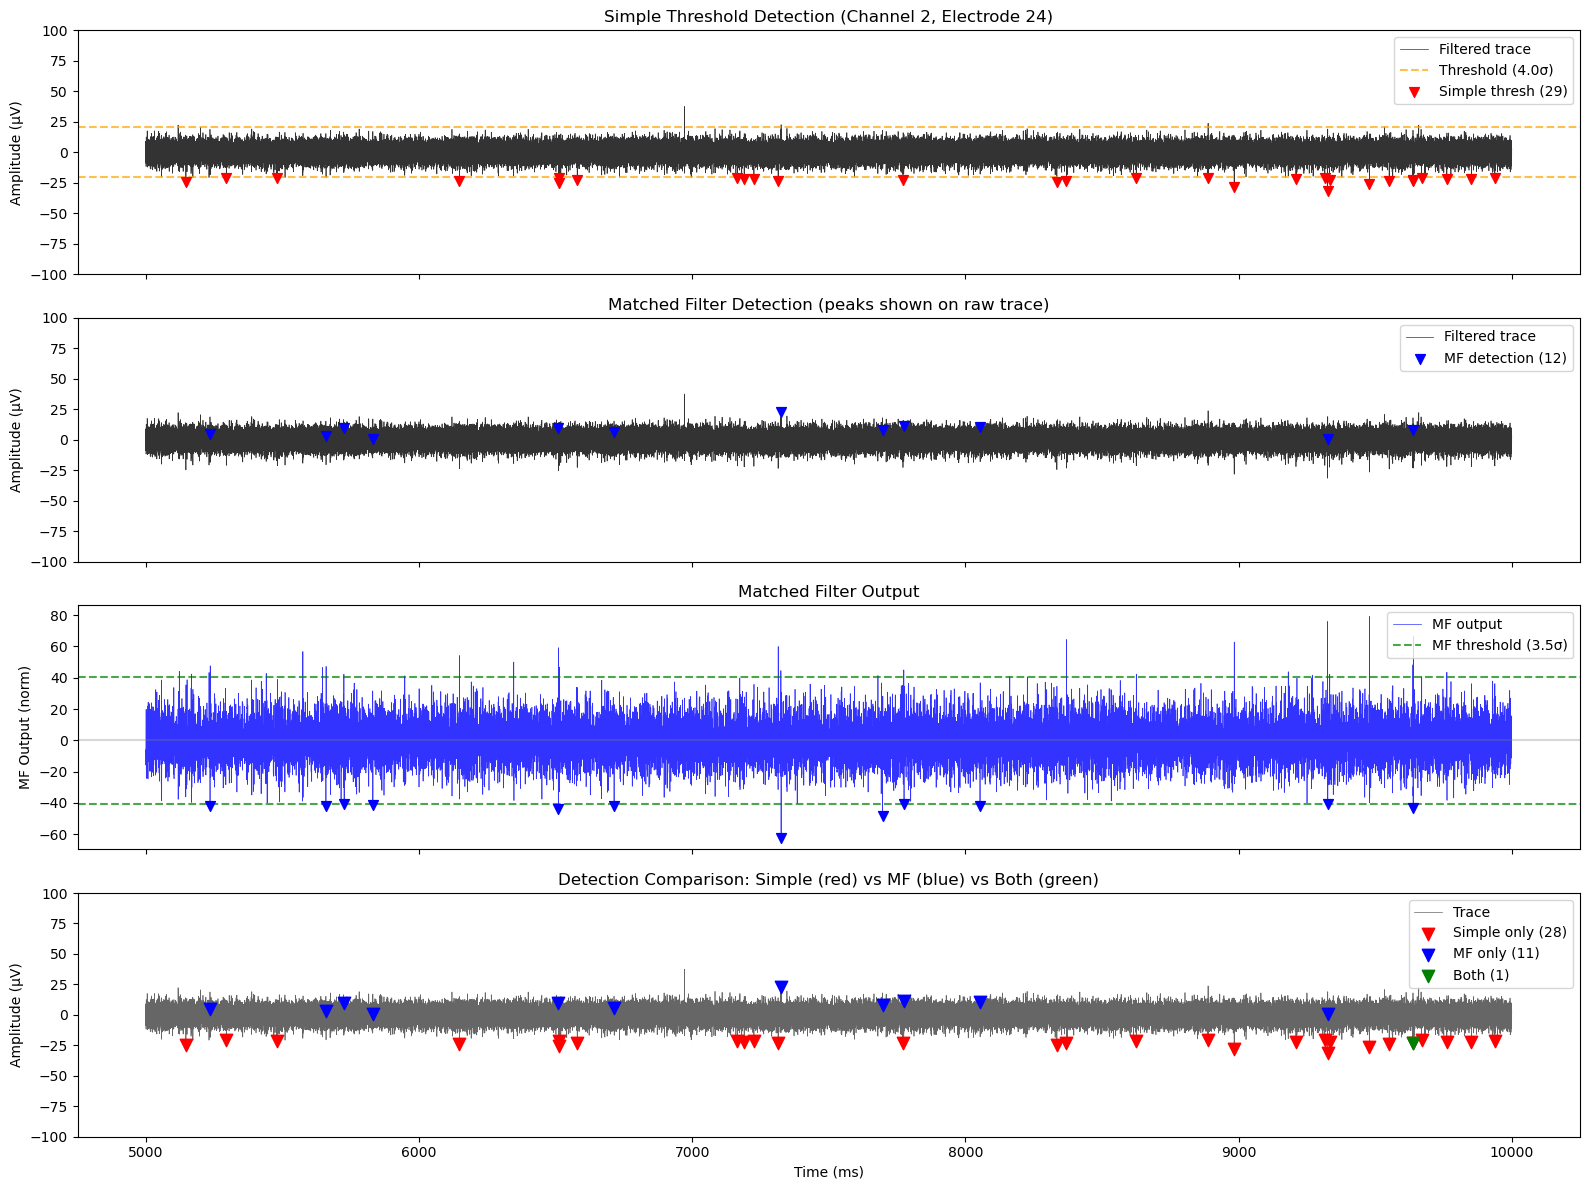


=== SUMMARY ===
Simple threshold: 29 detections
Matched filter:   12 detections
Agreement:        1 peaks detected by both
Simple only:      28 (may be noise or different waveforms)
MF only:          11 (template matched but below amp threshold)


In [43]:
# === COMPARISON VISUALIZATION ===

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Panel 1: Raw trace with simple threshold detections
ax = axes[0]
ax.plot(t_ms, trace, 'k-', lw=0.5, alpha=0.8, label='Filtered trace')
ax.axhline(-thresh_uV, color='orange', linestyle='--', alpha=0.7, label=f'Threshold ({THRESH_SIMPLE}σ)')
ax.axhline(thresh_uV, color='orange', linestyle='--', alpha=0.7)
if len(simple_peak_idx) > 0:
    ax.scatter(t_ms[simple_peak_idx], simple_peak_amp, 
               c='red', s=50, marker='v', zorder=5, label=f'Simple thresh ({len(simple_peak_idx)})')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Simple Threshold Detection (Channel {debug_ch_idx}, Electrode {DEBUG_ELECTRODE})')
ax.legend(loc='upper right')
ax.set_ylim(-100, 100)  # Adjust as needed

# Panel 2: Raw trace with matched filter detections
ax = axes[1]
ax.plot(t_ms, trace, 'k-', lw=0.5, alpha=0.8, label='Filtered trace')
if len(mf_peak_idx) > 0:
    ax.scatter(t_ms[mf_peak_idx], trace[mf_peak_idx], 
               c='blue', s=50, marker='v', zorder=5, label=f'MF detection ({len(mf_peak_idx)})')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Matched Filter Detection (peaks shown on raw trace)')
ax.legend(loc='upper right')
ax.set_ylim(-100, 100)

# Panel 3: Matched filter output
ax = axes[2]
ax.plot(t_ms, mf_output_norm, 'b-', lw=0.5, alpha=0.8, label='MF output')
ax.axhline(-mf_thresh, color='green', linestyle='--', alpha=0.7, label=f'MF threshold ({THRESH_MF}σ)')
ax.axhline(mf_thresh, color='green', linestyle='--', alpha=0.7)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
if len(mf_peak_idx) > 0:
    ax.scatter(t_ms[mf_peak_idx], mf_peak_amp, 
               c='blue', s=50, marker='v', zorder=5)
ax.set_ylabel('MF Output (norm)')
ax.set_title('Matched Filter Output')
ax.legend(loc='upper right')

# Panel 4: Comparison overlay
ax = axes[3]
ax.plot(t_ms, trace, 'k-', lw=0.5, alpha=0.6, label='Trace')

# Mark simple-only detections (red)
# Mark MF-only detections (blue)  
# Mark both detections (green)

simple_set = set(simple_peak_idx)
mf_set = set(mf_peak_idx)

# Find matches (within 0.5ms tolerance)
tolerance_samp = int(0.5 * fs / 1000)
matched_simple = []
matched_mf = []
for s in simple_peak_idx:
    for m in mf_peak_idx:
        if abs(s - m) <= tolerance_samp:
            matched_simple.append(s)
            matched_mf.append(m)
            break

simple_only = [s for s in simple_peak_idx if s not in matched_simple]
mf_only = [m for m in mf_peak_idx if m not in matched_mf]
both = matched_simple

if len(simple_only) > 0:
    ax.scatter(t_ms[simple_only], trace[simple_only], 
               c='red', s=80, marker='v', zorder=5, label=f'Simple only ({len(simple_only)})')
if len(mf_only) > 0:
    ax.scatter(t_ms[mf_only], trace[mf_only], 
               c='blue', s=80, marker='v', zorder=5, label=f'MF only ({len(mf_only)})')
if len(both) > 0:
    ax.scatter(t_ms[both], trace[both], 
               c='green', s=80, marker='v', zorder=5, label=f'Both ({len(both)})')

ax.set_ylabel('Amplitude (µV)')
ax.set_xlabel('Time (ms)')
ax.set_title('Detection Comparison: Simple (red) vs MF (blue) vs Both (green)')
ax.legend(loc='upper right')
ax.set_ylim(-100, 100)

plt.tight_layout()
plt.savefig('detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== SUMMARY ===")
print(f"Simple threshold: {len(simple_peak_idx)} detections")
print(f"Matched filter:   {len(mf_peak_idx)} detections")
print(f"Agreement:        {len(both)} peaks detected by both")
print(f"Simple only:      {len(simple_only)} (may be noise or different waveforms)")
print(f"MF only:          {len(mf_only)} (template matched but below amp threshold)")


=== Extracting waveforms around detected peaks ===


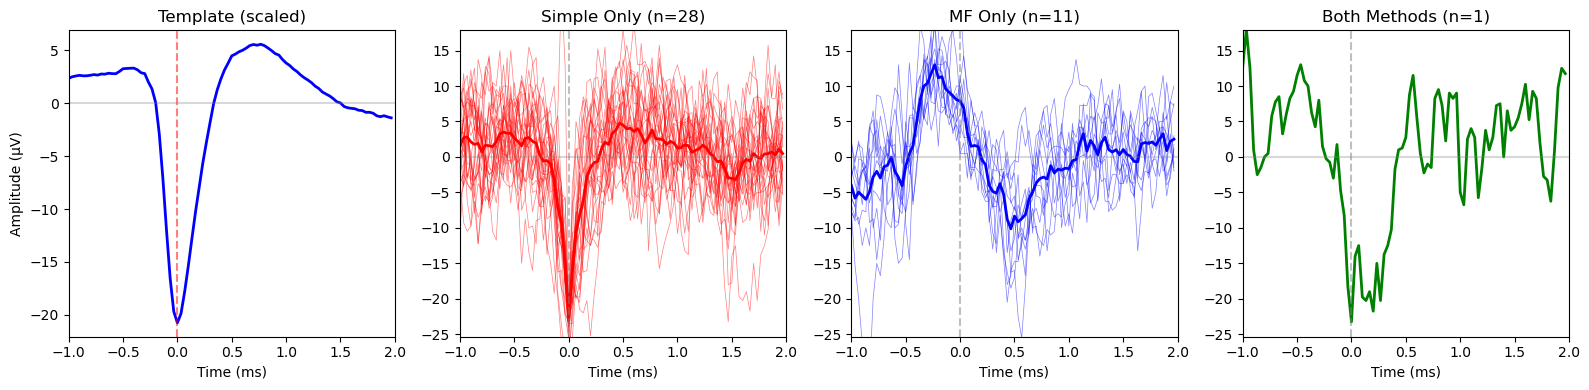

In [44]:
# === WAVEFORM EXTRACTION FOR DETECTED PEAKS ===

print("\n=== Extracting waveforms around detected peaks ===")

# Parameters for waveform extraction
wf_ms_before = 1.0
wf_ms_after = 2.0
wf_samp_before = int(wf_ms_before * fs / 1000)
wf_samp_after = int(wf_ms_after * fs / 1000)
wf_len = wf_samp_before + wf_samp_after

def extract_waveforms(trace, peak_indices, n_before, n_after):
    """Extract waveforms around peak indices."""
    waveforms = []
    valid_indices = []
    for idx in peak_indices:
        start = idx - n_before
        end = idx + n_after
        if start >= 0 and end <= len(trace):
            waveforms.append(trace[start:end])
            valid_indices.append(idx)
    return np.array(waveforms), np.array(valid_indices)

# Extract waveforms for each category
wf_simple_only, idx_simple_only = extract_waveforms(trace, simple_only, wf_samp_before, wf_samp_after)
wf_mf_only, idx_mf_only = extract_waveforms(trace, mf_only, wf_samp_before, wf_samp_after)
wf_both, idx_both = extract_waveforms(trace, both, wf_samp_before, wf_samp_after)

t_wf = (np.arange(wf_len) - wf_samp_before) / fs * 1000

# Plot waveform comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Template (scaled to typical amplitude)
ax = axes[0]
template_scaled = template * thresh_uV / abs(template.min())  # Scale to threshold
t_template_plot = (np.arange(len(template)) - nbefore) / fs * 1000
ax.plot(t_template_plot, template_scaled, 'b-', lw=2)
ax.axvline(0, color='r', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Template (scaled)')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Simple only waveforms
ax = axes[1]
if len(wf_simple_only) > 0:
    for wf in wf_simple_only:
        ax.plot(t_wf, wf, 'r-', lw=0.5, alpha=0.5)
    ax.plot(t_wf, np.mean(wf_simple_only, axis=0), 'r-', lw=2, label='Mean')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title(f'Simple Only (n={len(wf_simple_only)})')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# MF only waveforms
ax = axes[2]
if len(wf_mf_only) > 0:
    for wf in wf_mf_only:
        ax.plot(t_wf, wf, 'b-', lw=0.5, alpha=0.5)
    ax.plot(t_wf, np.mean(wf_mf_only, axis=0), 'b-', lw=2, label='Mean')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title(f'MF Only (n={len(wf_mf_only)})')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Both waveforms
ax = axes[3]
if len(wf_both) > 0:
    for wf in wf_both:
        ax.plot(t_wf, wf, 'g-', lw=0.5, alpha=0.5)
    ax.plot(t_wf, np.mean(wf_both, axis=0), 'g-', lw=2, label='Mean')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (ms)')
ax.set_title(f'Both Methods (n={len(wf_both)})')
ax.set_xlim(-wf_ms_before, wf_ms_after)

# Sync y-axes
all_wfs = []
if len(wf_simple_only) > 0: all_wfs.extend(wf_simple_only.flatten())
if len(wf_mf_only) > 0: all_wfs.extend(wf_mf_only.flatten())
if len(wf_both) > 0: all_wfs.extend(wf_both.flatten())
if all_wfs:
    ymin, ymax = np.percentile(all_wfs, [1, 99])
    yrange = ymax - ymin
    for ax in axes[1:]:
        ax.set_ylim(ymin - 0.1*yrange, ymax + 0.1*yrange)

plt.tight_layout()
plt.savefig('waveform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


=== Template Correlation Analysis ===


C:\Users\culle\AppData\Local\Temp\ipykernel_34844\2055616407.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


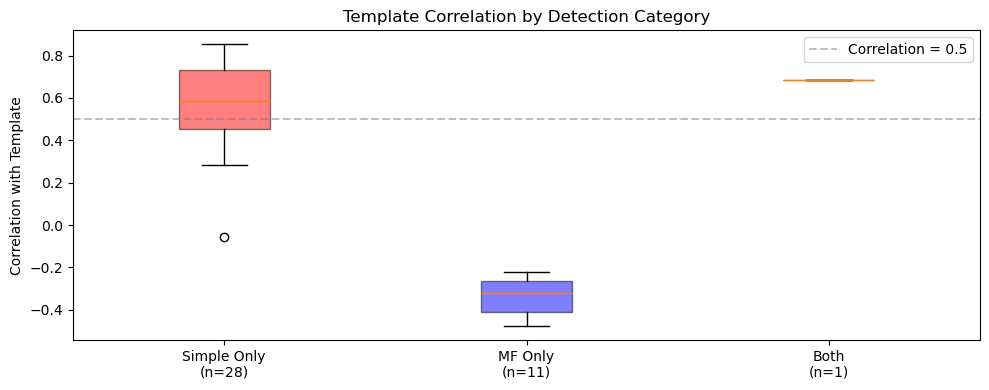


Correlation Statistics:
  Simple Only: mean=0.573, std=0.200
  MF Only:     mean=-0.336, std=0.093
  Both:        mean=0.685, std=0.000


In [45]:
# === CORRELATION ANALYSIS ===

print("\n=== Template Correlation Analysis ===")

def compute_correlation(waveform, template):
    """Compute normalized correlation between waveform and template."""
    # Align by resampling if needed (assuming same sample rate)
    # Truncate/pad to same length
    min_len = min(len(waveform), len(template))
    wf = waveform[:min_len]
    tmpl = template[:min_len]
    
    # Normalize
    wf_norm = (wf - np.mean(wf)) / (np.std(wf) + 1e-10)
    tmpl_norm = (tmpl - np.mean(tmpl)) / (np.std(tmpl) + 1e-10)
    
    # Correlation
    corr = np.corrcoef(wf_norm, tmpl_norm)[0, 1]
    return corr

# Compute correlations for each category
corr_simple_only = []
corr_mf_only = []
corr_both = []

# Align template to waveform extraction window
template_aligned = np.zeros(wf_len)
template_start = wf_samp_before - nbefore
template_end = template_start + len(template)
if template_start >= 0 and template_end <= wf_len:
    template_aligned[template_start:template_end] = template
else:
    # Handle edge cases
    src_start = max(0, -template_start)
    src_end = min(len(template), wf_len - template_start)
    dst_start = max(0, template_start)
    dst_end = dst_start + (src_end - src_start)
    template_aligned[dst_start:dst_end] = template[src_start:src_end]

for wf in wf_simple_only:
    corr_simple_only.append(compute_correlation(wf, template_aligned))
for wf in wf_mf_only:
    corr_mf_only.append(compute_correlation(wf, template_aligned))
for wf in wf_both:
    corr_both.append(compute_correlation(wf, template_aligned))

# Plot correlation distributions
fig, ax = plt.subplots(figsize=(10, 4))

data = []
labels = []
colors = []

if len(corr_simple_only) > 0:
    data.append(corr_simple_only)
    labels.append(f'Simple Only\n(n={len(corr_simple_only)})')
    colors.append('red')
if len(corr_mf_only) > 0:
    data.append(corr_mf_only)
    labels.append(f'MF Only\n(n={len(corr_mf_only)})')
    colors.append('blue')
if len(corr_both) > 0:
    data.append(corr_both)
    labels.append(f'Both\n(n={len(corr_both)})')
    colors.append('green')

if data:
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Correlation = 0.5')
ax.set_ylabel('Correlation with Template')
ax.set_title('Template Correlation by Detection Category')
ax.legend()

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation Statistics:")
if len(corr_simple_only) > 0:
    print(f"  Simple Only: mean={np.mean(corr_simple_only):.3f}, std={np.std(corr_simple_only):.3f}")
if len(corr_mf_only) > 0:
    print(f"  MF Only:     mean={np.mean(corr_mf_only):.3f}, std={np.std(corr_mf_only):.3f}")
if len(corr_both) > 0:
    print(f"  Both:        mean={np.mean(corr_both):.3f}, std={np.std(corr_both):.3f}")

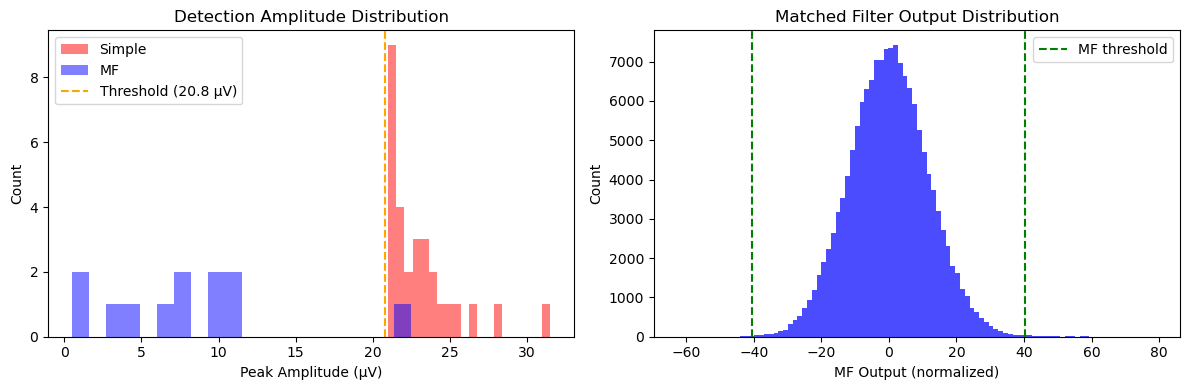

In [46]:
# === AMPLITUDE HISTOGRAM ===

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw amplitude histogram
ax = axes[0]
if len(simple_peak_amp) > 0:
    ax.hist(np.abs(simple_peak_amp), bins=20, alpha=0.5, color='red', label='Simple')
if len(trace[mf_peak_idx]) > 0:
    ax.hist(np.abs(trace[mf_peak_idx]), bins=20, alpha=0.5, color='blue', label='MF')
ax.axvline(thresh_uV, color='orange', linestyle='--', label=f'Threshold ({thresh_uV:.1f} µV)')
ax.set_xlabel('Peak Amplitude (µV)')
ax.set_ylabel('Count')
ax.set_title('Detection Amplitude Distribution')
ax.legend()

# MF output histogram
ax = axes[1]
ax.hist(mf_output_norm, bins=100, alpha=0.7, color='blue')
ax.axvline(-mf_thresh, color='green', linestyle='--', label=f'MF threshold')
ax.axvline(mf_thresh, color='green', linestyle='--')
ax.set_xlabel('MF Output (normalized)')
ax.set_ylabel('Count')
ax.set_title('Matched Filter Output Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('amplitude_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# === MULTI-CHANNEL OVERVIEW ===

print("\n=== Running detection on multiple channels ===")

# Sample a few channels across the array
n_channels = rec.get_num_channels()
sample_channels = np.linspace(0, n_channels-1, min(8, n_channels), dtype=int)

results = []

for ch_idx in sample_channels:
    ch_id = ch_ids[ch_idx]
    
    # Get trace
    tr = rec.get_traces(
        start_frame=t0_samp, 
        end_frame=t1_samp, 
        channel_ids=[ch_id],
        return_in_uV=True
    ).flatten()
    
    # Noise level
    noise = np.median(np.abs(tr - np.median(tr))) / 0.6745
    thresh = THRESH_SIMPLE * noise
    
    # Simple detection
    if PEAK_SIGN == "neg":
        below = tr < -thresh
    else:
        below = tr > thresh
    n_simple = np.sum(np.diff(below.astype(int)) == 1)
    
    # MF detection
    mf_out = correlate(tr, template, mode='same')
    mf_out_norm = mf_out / template_energy
    mf_n = np.median(np.abs(mf_out_norm - np.median(mf_out_norm))) / 0.6745
    mf_t = THRESH_MF * mf_n
    
    if PEAK_SIGN == "neg":
        mf_below = mf_out_norm < -mf_t
    else:
        mf_below = mf_out_norm > mf_t
    n_mf = np.sum(np.diff(mf_below.astype(int)) == 1)
    
    results.append({
        'ch_idx': ch_idx,
        'noise': noise,
        'n_simple': n_simple,
        'n_mf': n_mf,
        'ratio': n_mf / max(n_simple, 1)
    })

# Display results
print(f"\n{'Ch Idx':<8} {'Noise (µV)':<12} {'Simple':<10} {'MF':<10} {'Ratio':<10}")
print("-" * 50)
for r in results:
    print(f"{r['ch_idx']:<8} {r['noise']:<12.1f} {r['n_simple']:<10} {r['n_mf']:<10} {r['ratio']:<10.2f}")


=== Running detection on multiple channels ===

Ch Idx   Noise (µV)   Simple     MF         Ratio     
--------------------------------------------------
0        6.3          31         11         0.35      
18       5.9          169        12         0.07      
36       3.7          10         6          0.60      
54       4.1          80         12         0.15      
72       3.3          13         9          0.69      
90       4.4          33         17         0.52      
108      5.2          282        40         0.14      
127      11.1         536        78         0.15      



Zooming into first spike detected by both methods:


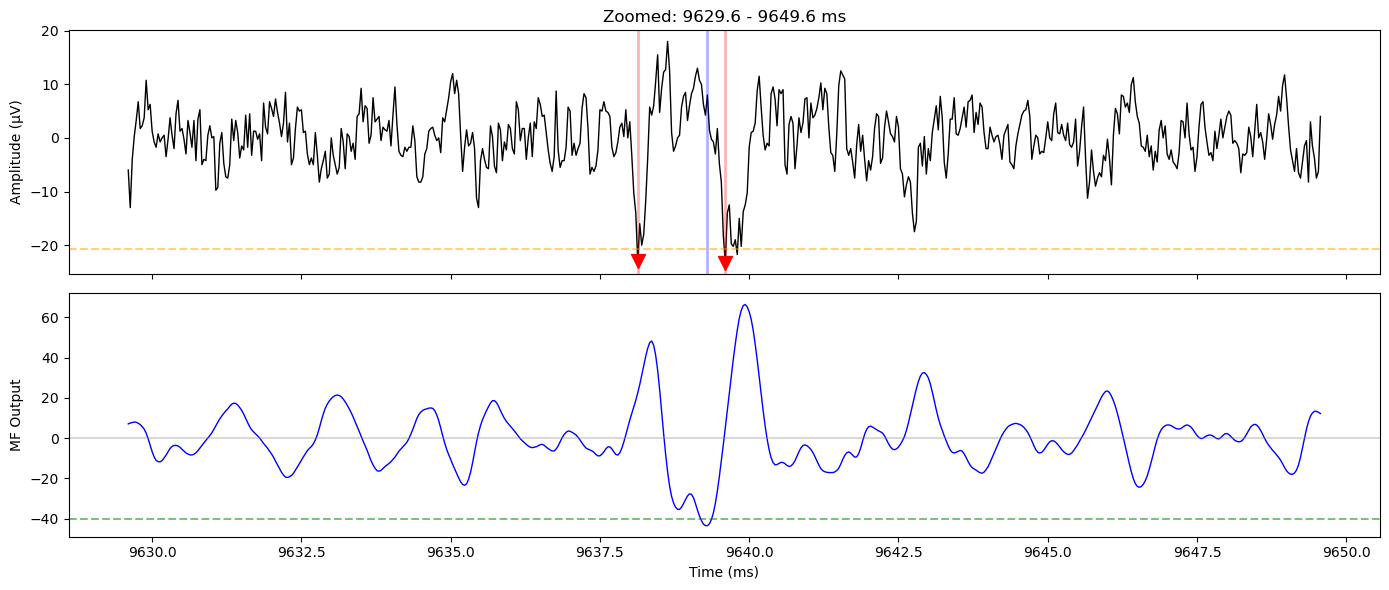

In [48]:
# === INTERACTIVE ZOOMING (optional) ===

def plot_zoom_window(center_ms, window_ms=50):
    """Plot a zoomed view around a specific time."""
    t0 = center_ms - window_ms/2
    t1 = center_ms + window_ms/2
    
    mask = (t_ms >= t0) & (t_ms <= t1)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    ax = axes[0]
    ax.plot(t_ms[mask], trace[mask], 'k-', lw=1)
    ax.axhline(-thresh_uV, color='orange', linestyle='--', alpha=0.5)
    
    # Mark detections in this window
    for idx in simple_peak_idx:
        if t0 <= t_ms[idx] <= t1:
            ax.axvline(t_ms[idx], color='red', alpha=0.3, lw=2)
            ax.scatter([t_ms[idx]], [trace[idx]], c='red', s=100, marker='v', zorder=5)
    
    for idx in mf_peak_idx:
        if t0 <= t_ms[idx] <= t1:
            ax.axvline(t_ms[idx], color='blue', alpha=0.3, lw=2)
    
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(f'Zoomed: {t0:.1f} - {t1:.1f} ms')
    
    ax = axes[1]
    ax.plot(t_ms[mask], mf_output_norm[mask], 'b-', lw=1)
    ax.axhline(-mf_thresh, color='green', linestyle='--', alpha=0.5)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_ylabel('MF Output')
    ax.set_xlabel('Time (ms)')
    
    plt.tight_layout()
    plt.show()

# Example: zoom into first detected spike
if len(both) > 0:
    print("\nZooming into first spike detected by both methods:")
    plot_zoom_window(t_ms[both[0]], window_ms=20)
elif len(simple_peak_idx) > 0:
    print("\nZooming into first simple threshold detection:")
    plot_zoom_window(t_ms[simple_peak_idx[0]], window_ms=20)

In [49]:
print("\n" + "="*60)
print("DIAGNOSTIC COMPLETE")
print("="*60)
print("""
Key things to look for:
1. If 'Simple Only' has many detections with LOW correlation:
   → These are likely noise or different waveform shapes
   → The template may not represent all spike types

2. If 'MF Only' has detections with HIGH correlation but low amplitude:
   → Template matching found small but "real" spikes
   → Consider lowering simple threshold

3. If 'Both' has high correlation values:
   → Good! The methods agree on clear spikes

4. If MF finds very few spikes:
   → Template may not match actual spikes in this recording
   → Try creating a new template from THIS session

5. Look at the waveform plots:
   → Do 'Simple Only' waveforms look like spikes?
   → Do 'MF Only' waveforms match the template?
""")


DIAGNOSTIC COMPLETE

Key things to look for:
1. If 'Simple Only' has many detections with LOW correlation:
   → These are likely noise or different waveform shapes
   → The template may not represent all spike types

2. If 'MF Only' has detections with HIGH correlation but low amplitude:
   → Template matching found small but "real" spikes
   → Consider lowering simple threshold

3. If 'Both' has high correlation values:
   → Good! The methods agree on clear spikes

4. If MF finds very few spikes:
   → Template may not match actual spikes in this recording
   → Try creating a new template from THIS session

5. Look at the waveform plots:
   → Do 'Simple Only' waveforms look like spikes?
   → Do 'MF Only' waveforms match the template?

